## Environment Setup and Dependencies

In [1]:
from datetime import datetime
start_time = datetime.now()

In [2]:
import os
import re
import time
import pickle
import random
import warnings
import tarfile
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import psutil
from PIL import Image
from scipy import ndimage
from scipy.ndimage import gaussian_filter
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.random_projection import SparseRandomProjection
from skimage.measure import label, regionprops

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import timm
from tqdm import tqdm
import torchvision

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


# Constants and Data Preperation

In [3]:
TAR_PATH = "/kaggle/input/datasets/naimur978/mvtec-carpet/carpet.tar.xz"
DATA_DIR = Path("/kaggle/working/")
OUTPUT_DIR = Path('/kaggle/working/outputs')
MODEL_DIR = Path('/kaggle/working/models')
RESULTS_DIR = Path('/kaggle/working/results')


TARGET_CATEGORY = "carpet"
MODEL_NAME = 'dinov2_vitb14'
FEATURE_DIM = None
PATCH_SIZE = 14

K_SHOT = 4
USE_FEW_SHOT = False

IMG_SIZE = (224, 224)
NORMALIZE_MEAN = (0.485, 0.456, 0.406)
NORMALIZE_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 32
NUM_WORKERS = 2

DISTANCE_METRIC = 'cosine'
TOP_K_NEIGHBORS = 5

SEED = 42
VERBOSE = True
SAVE_PREDICTIONS = True
SAVE_VISUALIZATIONS = True

# Multi-scale settings
use_multi_scale: bool = True
multi_scales: list = field(default_factory=lambda: [0.5, 1.0, 2.0])  # Downscale, original, upscale
feature_dim_multi_scale: int = 768 * 3  # 2304

with tarfile.open(TAR_PATH, "r:xz") as tar:
    tar.extractall(path=DATA_DIR)

cats = sorted(d for d in os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR / d))

@dataclass
class Config:
    data_dir: Path = field(default_factory=lambda: DATA_DIR)
    output_dir: Path = field(default_factory=lambda: OUTPUT_DIR)
    model_dir: Path = field(default_factory=lambda: MODEL_DIR)
    results_dir: Path = field(default_factory=lambda: RESULTS_DIR)
    
    target_category: str = TARGET_CATEGORY
    categories: List[str] = field(default_factory=list)
    
    model_name: str = MODEL_NAME
    feature_dim: int = FEATURE_DIM
    patch_size: int = PATCH_SIZE
    
    k_shot: int = K_SHOT
    use_few_shot: bool = USE_FEW_SHOT
    
    img_size: Tuple[int, int] = IMG_SIZE
    normalize_mean: Tuple[float, float, float] = NORMALIZE_MEAN
    normalize_std: Tuple[float, float, float] = NORMALIZE_STD
    
    batch_size: int = BATCH_SIZE
    num_workers: int = NUM_WORKERS
    
    memory_bank_size: Optional[int] = None
    distance_metric: str = DISTANCE_METRIC
    anomaly_threshold: Optional[float] = None
    top_k_neighbors: int = TOP_K_NEIGHBORS
    
    device: str = field(default_factory=lambda: 'cuda' if torch.cuda.is_available() else 'cpu')
    seed: int = SEED
    
    verbose: bool = VERBOSE
    save_predictions: bool = SAVE_PREDICTIONS
    save_visualizations: bool = SAVE_VISUALIZATIONS
    
    def __post_init__(self):
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.results_dir.mkdir(parents=True, exist_ok=True)
        
        if not self.data_dir.exists():
            raise FileNotFoundError(f"Dataset not found at {self.data_dir}")
        
        all_cats = sorted([d for d in os.listdir(self.data_dir) if os.path.isdir(self.data_dir / d)])
        if self.target_category not in all_cats:
            raise ValueError(f"target_category='{self.target_category}' does not exist. Available: {all_cats}")
        
        self.categories = [self.target_category]
    
    def display(self):
        print("=" * 80)
        print("CONFIGURATION SETTINGS")
        print("=" * 80)
        print(f"Data dir:        {self.data_dir}")
        print(f"Output dir:      {self.output_dir}")
        print(f"Model dir:       {self.model_dir}")
        print(f"Results dir:     {self.results_dir}")

        print(f"\nModel: {self.model_name} | feat_dim={self.feature_dim} | patch={self.patch_size}")
        print(f"Img size: {self.img_size} | metric={self.distance_metric} | topk={self.top_k_neighbors}")
        print(f"Device: {self.device}" + (f" | GPU: {torch.cuda.get_device_name(0)}" if self.device=="cuda" else ""))
        print("=" * 80)

config = Config()
config.display()

CONFIGURATION SETTINGS
Data dir:        /kaggle/working
Output dir:      /kaggle/working/outputs
Model dir:       /kaggle/working/models
Results dir:     /kaggle/working/results

Model: dinov2_vitb14 | feat_dim=None | patch=14
Img size: (224, 224) | metric=cosine | topk=5
Device: cuda | GPU: Tesla P100-PCIE-16GB


# Data Exploration and Visualization

In [4]:
def get_category_stats(data_dir: Path, category: str) -> dict:
    p = data_dir / category
    count = lambda d: len(list(d.glob('*.png'))) if d.exists() else 0
    test = p / 'test'
    anomaly_types = [d.name for d in test.iterdir() if d.is_dir() and d.name != 'good'] if test.exists() else []
    return {
        'Category': category,
        'Train (Normal)': count(p / 'train' / 'good'),
        'Test (Normal)': (tg := count(test / 'good')),
        'Test (Anomaly)': (ta := sum(count(test / a) for a in anomaly_types)),
        'Anomaly Types': len(anomaly_types),
        'Total Categories': len(cats),
        'Total Test': tg + ta,
    }

pd.DataFrame([get_category_stats(DATA_DIR, "carpet")])

,Category,Train (Normal),Test (Normal),Test (Anomaly),Anomaly Types,Total Categories,Total Test
0,carpet,280,28,89,5,1,117


Size: 1024x1024


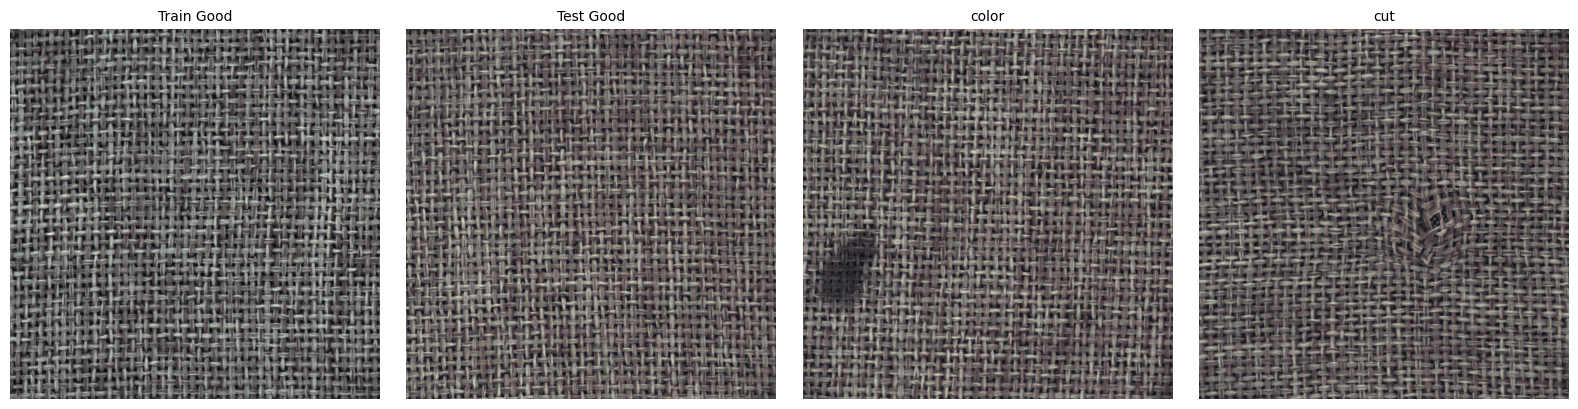

In [5]:
def count_png(folder: Path) -> int:
    return len(list(folder.glob("*.png"))) if folder.exists() else 0

def show_random_images(data_dir: Path, category: str):
    base    = data_dir / category
    train   = base / "train" / "good"
    test    = base / "test"
    good    = test / "good"
    defects = sorted(d.name for d in test.iterdir() if d.is_dir() and d.name != "good") if test.exists() else []

    img = next(iter(train.glob("*.png")), None)
    img = Image.open(img) if img else None
    w, h = img.size if img else (None, None)

    print(f"Size: {w}x{h}")

    samples = (list(train.glob("*.png"))[:1] + list(good.glob("*.png"))[:1] +
               [next((test/d).glob("*.png")) for d in defects[:2] if list((test/d).glob("*.png"))])
    titles  = ["Train Good", "Test Good"] + defects[:2]

    fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 4))
    for ax, f, t in zip(axes, samples, titles):
        ax.imshow(Image.open(f)); ax.set_title(t, fontsize=10); ax.axis("off")
    plt.tight_layout(); plt.show()

show_random_images(DATA_DIR, "carpet")

# Data Preprocessing

In [6]:
class ImageTransforms:
    @staticmethod
    def get_train_transforms(img_size, mean, std):
        return T.Compose([T.Resize(img_size), T.ToTensor(), T.Normalize(mean=mean, std=std)])

    @staticmethod
    def get_test_transforms(img_size, mean, std):
        return T.Compose([T.Resize(img_size), T.ToTensor(), T.Normalize(mean=mean, std=std)])


class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, split='train', transform=None):
        self.root_dir, self.category, self.split, self.transform = Path(root_dir), category, split, transform
        self.image_paths, self.labels, self.defect_types = [], [], []
        self._load_data()

    def _load_data(self):
        base = self.root_dir / self.category / self.split
        if self.split == 'train':
            for p in sorted((base / 'good').glob('*.png')):
                self.image_paths.append(p); self.labels.append(0); self.defect_types.append('good')
        elif base.exists():
            for d in sorted(d for d in base.iterdir() if d.is_dir()):
                for p in sorted(d.glob('*.png')):
                    self.image_paths.append(p)
                    self.labels.append(0 if d.name == 'good' else 1)
                    self.defect_types.append(d.name)

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return {'image': img, 'label': self.labels[idx],
                'defect_type': self.defect_types[idx], 'path': str(self.image_paths[idx])}


def create_few_shot_loader(dataset, k_shot, batch_size, shuffle=False, num_workers=2, device="cpu", seed=42):
    if k_shot is not None and k_shot < len(dataset):
        dataset = Subset(dataset, random.Random(seed).sample(range(len(dataset)), k_shot))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=num_workers, pin_memory=device == 'cuda')


def build_loaders_for_one_category(config, category=None, visualize_batch=True):
    category = category or config.target_category
    train_transform = ImageTransforms.get_train_transforms(config.img_size, config.normalize_mean, config.normalize_std)
    test_transform  = ImageTransforms.get_test_transforms(config.img_size, config.normalize_mean, config.normalize_std)

    train_dataset = MVTecDataset(config.data_dir, category, 'train', train_transform)
    test_dataset  = MVTecDataset(config.data_dir, category, 'test',  test_transform)

    train_loader = create_few_shot_loader(
        train_dataset, k_shot=config.k_shot if config.use_few_shot else None,
        batch_size=config.batch_size, num_workers=config.num_workers,
        device=config.device, seed=config.seed,
    )
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                             shuffle=False, num_workers=config.num_workers,
                             pin_memory=config.device == 'cuda')

    return train_dataset, test_dataset, train_loader, test_loader


carpet_config = Config(target_category="carpet") 

carpet_train_ds, carpet_test_ds, carpet_train_loader, carpet_test_loader = build_loaders_for_one_category(carpet_config)

# Feature Extraction

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 477MB/s]


Patches: 256 | Shape: torch.Size([32, 256, 2304]) | Range: [-17.430, 26.433]
Mean: -0.0267 | Std: 1.7178 | L2: 82.4035
Memory/img: 0.75 MB | Total train: 210.00 MB


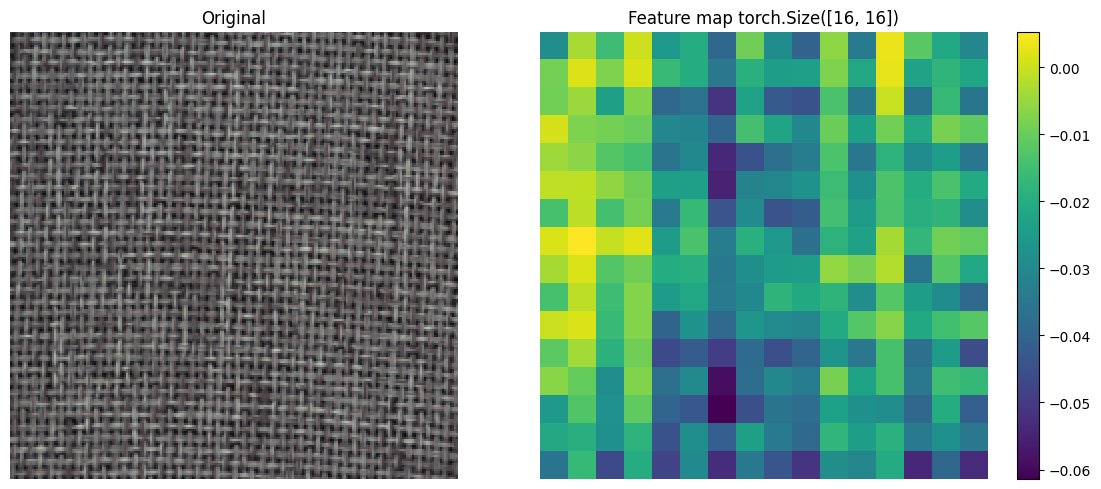

In [7]:
class DINOv2FeatureExtractor(nn.Module):
    def __init__(self, model_name='dinov2_vitb14', device='cuda'):
        super().__init__()
        self.model_name, self.device = model_name, device
        self.model = torch.hub.load('facebookresearch/dinov2', model_name).to(device)
        for p in self.model.parameters(): p.requires_grad = False
        self.model.eval()
        self.feature_dim = self.model.embed_dim
        self.patch_size  = self.model.patch_size
        self.scales      = [0.5, 1.0, 2.0]

    def forward(self, x):
        B, C, H, W = x.shape
        with torch.no_grad():
            features = []
            for scale in self.scales:
                xs = x if scale == 1.0 else F.interpolate(x, size=(int(H*scale), int(W*scale)),
                                                           mode='bilinear', align_corners=False)
                tokens = self.model.forward_features(xs)['x_norm_patchtokens']
                features.append(self._normalize_patch_grid(tokens, scale, H, W))
        return torch.cat(features, dim=-1)

    def _normalize_patch_grid(self, features, scale, orig_h, orig_w):
        B, _, feat_dim = features.shape
        gh, gw   = int(orig_h * scale) // self.patch_size, int(orig_w * scale) // self.patch_size
        ogh, ogw = orig_h // self.patch_size, orig_w // self.patch_size
        grid = features.view(B, gh, gw, feat_dim).permute(0, 3, 1, 2)
        if scale != 1.0:
            mode = 'nearest' if scale < 1.0 else 'adaptive'
            grid = (F.interpolate(grid, size=(ogh, ogw), mode='nearest') if scale < 1.0
                    else F.adaptive_avg_pool2d(grid, (ogh, ogw)))
        return grid.permute(0, 2, 3, 1).reshape(B, ogh * ogw, feat_dim)

    def extract_features(self, dataloader, max_samples=None):
        self.model.eval()
        all_features, all_labels = [], []
        with torch.no_grad():
            for i, batch in enumerate(tqdm(dataloader, desc="Extracting features")):
                if max_samples and i * dataloader.batch_size >= max_samples: break
                all_features.append(self.forward(batch['image'].to(self.device)).cpu())
                all_labels.append(batch['label'])
        return torch.cat(all_features), torch.cat(all_labels)

    def get_num_patches(self, img_size):
        return (img_size[0] // self.patch_size) * (img_size[1] // self.patch_size)


carpet_feature_extractor = DINOv2FeatureExtractor(carpet_config.model_name, carpet_config.device)

num_patches = carpet_feature_extractor.get_num_patches(carpet_config.img_size)
carpet_sample_images = next(iter(carpet_train_loader))['image'].to(carpet_config.device)

with torch.no_grad():
    sample_features = carpet_feature_extractor(carpet_sample_images)

feature_memory_mb = (num_patches * carpet_feature_extractor.feature_dim * 4) / (1024**2)
print(f"Patches: {num_patches} | Shape: {sample_features.shape} | Range: [{sample_features.min():.3f}, {sample_features.max():.3f}]")
print(f"Mean: {sample_features.mean():.4f} | Std: {sample_features.std():.4f} | L2: {torch.norm(sample_features, dim=-1).mean():.4f}")
print(f"Memory/img: {feature_memory_mb:.2f} MB | Total train: {len(carpet_train_ds) * feature_memory_mb:.2f} MB")

# Visualize
sample_img  = carpet_sample_images[0].cpu()
sample_feat = sample_features[0].cpu()
fig, axes   = plt.subplots(1, 2, figsize=(12, 5))

img_display = np.clip(sample_img.permute(1,2,0).numpy() * np.array(carpet_config.normalize_std) + np.array(carpet_config.normalize_mean), 0, 1)
axes[0].imshow(img_display); axes[0].set_title("Original"); axes[0].axis('off')

feat_map = sample_feat.mean(dim=-1).reshape(carpet_config.img_size[0] // carpet_feature_extractor.patch_size,
                                             carpet_config.img_size[1] // carpet_feature_extractor.patch_size)
im = axes[1].imshow(feat_map, cmap='viridis'); axes[1].set_title(f"Feature map {feat_map.shape}"); axes[1].axis('off')
plt.colorbar(im, ax=axes[1]); plt.tight_layout(); plt.show()

# Memory Bank Construction

In [8]:
class WideResNetUNet(nn.Module):
    def __init__(self, device='cuda'):
        super().__init__()
        self.device = device
        backbone = torchvision.models.wide_resnet50_2(weights=torchvision.models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
        self.enc0 = nn.Sequential(*list(backbone.children())[:3])
        self.enc1 = nn.Sequential(*list(backbone.children())[3:5])
        self.enc2 = nn.Sequential(list(backbone.children())[5])
        self.enc3 = nn.Sequential(list(backbone.children())[6])
        self.enc4 = nn.Sequential(list(backbone.children())[7])
        for enc in [self.enc0, self.enc1, self.enc2, self.enc3, self.enc4]:
            for p in enc.parameters(): p.requires_grad = False

        self.dec4 = self._block(2048 + 1024, 512)
        self.dec3 = self._block(512 + 512,   256)
        self.dec2 = self._block(256 + 256,   128)
        self.dec1 = self._block(128 + 64,     64)
        self.dec0 = self._block(64,            32)
        self.out  = nn.Conv2d(32, 3, 1)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, 1, 1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        e0 = self.enc0(x)
        e1 = self.enc1(e0)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        d = self.dec4(torch.cat([e4, F.interpolate(e3, e4.shape[2:], mode='bilinear', align_corners=False)], dim=1))
        d = self.dec3(torch.cat([d,  F.interpolate(e2, d.shape[2:],  mode='bilinear', align_corners=False)], dim=1))
        d = self.dec2(torch.cat([d,  F.interpolate(e1, d.shape[2:],  mode='bilinear', align_corners=False)], dim=1))
        d = self.dec1(torch.cat([d,  F.interpolate(e0, d.shape[2:],  mode='bilinear', align_corners=False)], dim=1))
        d = self.dec0(d)
        return torch.sigmoid(self.out(F.interpolate(d, x.shape[2:], mode='bilinear', align_corners=False)))

def train_unet(model, dataloader, device, epochs=50, lr=1e-4):
    model.to(device).train()
    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    pbar = tqdm(range(epochs), desc="Training UNet")
    for epoch in pbar:
        total = 0
        for batch in dataloader:
            x = batch['image'].to(device)
            loss = F.mse_loss(model(x), x)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        pbar.set_postfix(loss=f"{total/len(dataloader):.4f}")
    return model

def score_unet(model, dataloader, device):
    model.eval()
    image_scores, anomaly_maps, all_labels = [], [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Scoring"):
            x = batch['image'].to(device)
            recon = model(x)
            err = (x - recon).pow(2).mean(dim=1).cpu().numpy()
            anomaly_maps.append(err)
            image_scores.append(err.reshape(len(err), -1).max(axis=1))
            all_labels.append(batch['label'].numpy())
    return np.concatenate(image_scores), np.concatenate(anomaly_maps), np.concatenate(all_labels)

unet_model = WideResNetUNet().to(carpet_config.device)
print(f"Device: {next(unet_model.parameters()).device}")
unet_model = train_unet(unet_model, carpet_train_loader, carpet_config.device, epochs=50)

image_scores, anomaly_maps, test_labels = score_unet(unet_model, carpet_test_loader, carpet_config.device)
binary_labels = (test_labels > 0).astype(int)
image_auroc = roc_auc_score(binary_labels, image_scores)

print("=== U-Net Evaluation ===")
print(f"Image AUROC: {image_auroc:.4f}")

Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:08<00:00, 16.6MB/s]


Device: cuda:0


Scoring: 100%|██████████| 4/4 [00:03<00:00,  1.18it/s]

=== U-Net Evaluation ===
Image AUROC: 0.5269


# Anomaly Scoring

In [9]:
class AnomalyScorer:
    def __init__(self, memory_bank, feature_extractor, config):
        self.memory_bank = memory_bank
        self.feature_extractor = feature_extractor
        self.config = config

    def compute_anomaly_map(self, features):
        scores = self.memory_bank.get_knn_score(features, k=self.config.top_k_neighbors, metric=self.config.distance_metric)
        h, w = self.config.img_size[0] // self.feature_extractor.patch_size, self.config.img_size[1] // self.feature_extractor.patch_size
        return scores.reshape(h, w)

    def upsample_anomaly_map(self, anomaly_map):
        upsampled = cv2.resize(anomaly_map, (self.config.img_size[1], self.config.img_size[0]), interpolation=cv2.INTER_LINEAR)
        return gaussian_filter(upsampled, sigma=4)

    def score_batch(self, test_features):
        maps = [self.upsample_anomaly_map(self.compute_anomaly_map(test_features[i].numpy())) for i in range(len(test_features))]
        maps = np.array(maps)
        return maps.max(axis=(1, 2)), maps


carpet_scorer = AnomalyScorer(carpet_memory_bank, carpet_feature_extractor, carpet_config)

test_features, test_labels = carpet_feature_extractor.extract_features(carpet_test_loader)
image_scores, anomaly_maps = carpet_scorer.score_batch(test_features)

binary_labels = (test_labels.numpy() > 0).astype(int)
image_auroc = roc_auc_score(binary_labels, image_scores)
print(f"Image-level AUROC: {image_auroc:.4f}")

NameError: name 'carpet_memory_bank' is not defined

# Inference Speed Benchmark

In [ ]:
def process_rss_mb() -> float:
    return psutil.Process().memory_info().rss / 1024 / 1024

def gpu_alloc_mb() -> float:
    return (torch.cuda.memory_allocated() / 1024 / 1024) if torch.cuda.is_available() else 0.0

class SimpleBenchmark:
    def __init__(self, feature_extractor, memory_bank, scorer, config, device=None):
        self.feature_extractor = feature_extractor
        self.memory_bank = memory_bank
        self.scorer = scorer
        self.config = config
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def _sync(self):
        if torch.cuda.is_available(): torch.cuda.synchronize()

    def run(self, category, n_samples=50, warmup=5):
        cfg = self.config
        loader = DataLoader(
            MVTecDataset(cfg.data_dir, category, "test",
                transform=ImageTransforms.get_test_transforms(cfg.img_size, cfg.normalize_mean, cfg.normalize_std)),
            batch_size=1, shuffle=False, num_workers=0
        )
        it = iter(loader)
        for _ in range(min(warmup, len(loader))):
            with torch.no_grad():
                self.scorer.score_batch(self.feature_extractor(next(it)["image"].to(self.device)).cpu())
            self._sync()

        feat_ms, score_ms, e2e_ms = [], [], []
        for i, batch in enumerate(loader):
            if i >= n_samples: break
            imgs = batch["image"].to(self.device)
            self._sync(); t0 = time.perf_counter()
            with torch.no_grad():
                tf0 = time.perf_counter(); feats = self.feature_extractor(imgs); self._sync(); tf1 = time.perf_counter()
                ts0 = time.perf_counter(); self.scorer.score_batch(feats.cpu()); ts1 = time.perf_counter()
            self._sync(); t1 = time.perf_counter()
            feat_ms.append((tf1-tf0)*1000); score_ms.append((ts1-ts0)*1000); e2e_ms.append((t1-t0)*1000)

        feat_ms, score_ms, e2e_ms = map(np.asarray, [feat_ms, score_ms, e2e_ms])
        s = lambda a: (float(a.mean()), float(np.median(a)), float(a.min()), float(a.max()))
        keys = ["mean_ms","p50_ms","min_ms","max_ms"]
        timing = {f"feature_{k}": v for k,v in zip(keys,s(feat_ms))} | \
                 {f"scoring_{k}": v for k,v in zip(keys,s(score_ms))} | \
                 {f"e2e_{k}": v for k,v in zip(keys,s(e2e_ms))} | \
                 {"fps_mean": 1000/e2e_ms.mean()}
        mb = self.memory_bank.memory_bank
        return {
            "category": category, "device": str(self.device), "n_samples": len(e2e_ms),
            "timing": timing,
            "memory": {"memory_bank_mb": float(mb.nbytes/1024/1024), "process_cpu_rss_mb": process_rss_mb(), "gpu_allocated_mb": gpu_alloc_mb()},
            "raw_ms": {"feature_ms": feat_ms, "scoring_ms": score_ms, "e2e_ms": e2e_ms}
        }

def show_benchmark_table(r):
    t, m = r["timing"], r["memory"]
    display(pd.DataFrame([{"Category": r["category"], "Device": r["device"], "N": r["n_samples"],
        "Feature (ms)": round(t["feature_mean_ms"],3), "Scoring (ms)": round(t["scoring_mean_ms"],3),
        "E2E (ms)": round(t["e2e_mean_ms"],3), "FPS": round(t["fps_mean"],2),
        "MemBank (MB)": round(m["memory_bank_mb"],2), "CPU RSS (MB)": round(m["process_cpu_rss_mb"],2), "GPU (MB)": round(m["gpu_allocated_mb"],2)}]))

result = SimpleBenchmark(carpet_feature_extractor, carpet_memory_bank, carpet_scorer, carpet_config).run("carpet", n_samples=50, warmup=5)
show_benchmark_table(result)

# Heatmap to bounding box
https://stackoverflow.com/questions/58419893/generating-bounding-boxes-from-heatmap-data

In [ ]:
binary_labels = np.array(carpet_test_ds.labels) > 0
binary_labels = binary_labels.astype(int)
fpr, tpr, thresholds = roc_curve(binary_labels, image_scores)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

all_defects = set(carpet_test_ds.defect_types)
all_defects.discard('good')
all_defects = sorted(list(all_defects))

folders = ['good'] + all_defects
test_indices_per_folder = {folder: [] for folder in folders}

for i, defect_type in enumerate(carpet_test_ds.defect_types):
    test_indices_per_folder[defect_type].append(i)

test_data = []
for folder in folders:
    random_idx = random.choice(test_indices_per_folder[folder])
    test_data.append({
        'folder': folder,
        'idx': random_idx,
        'path': carpet_test_ds.image_paths[random_idx],
        'ground_truth': carpet_test_ds.labels[random_idx],
        'defect_type': carpet_test_ds.defect_types[random_idx],
        'score': image_scores[random_idx]
    })

print("\n" + "="*70)
print("STAGE 1: CLASSIFICATION")
print("="*70)
print(f"Optimal Threshold: {optimal_threshold:.4f}\n")

for data in test_data:
    predicted_label = 1 if data['score'] > optimal_threshold else 0
    ground_truth_text = "GOOD" if data['ground_truth'] == 0 else f"DEFECTIVE ({data['defect_type']})"
    predicted_text = "GOOD" if predicted_label == 0 else "DEFECTIVE"
    is_correct = "✓ CORRECT" if data['ground_truth'] == predicted_label else "✗ INCORRECT"

    print(f"{is_correct} {data['folder'].upper()}")
    print(f"   Ground Truth: {ground_truth_text}")
    print(f"   Prediction:   {predicted_text} (Score: {data['score']:.4f})")
    print()

print("="*70)
print("STAGE 2: LOCALIZATION")
print("="*70 + "\n")

fig, axes = plt.subplots(len(folders), 3, figsize=(15, 5 * len(folders)))

def get_bright_bbox(heatmap, threshold_percentile=75):
    heatmap_normalized = ((heatmap - heatmap.min()) / (heatmap.max() - heatmap.min()) * 255).astype(np.uint8)
    thresh = cv2.threshold(heatmap_normalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    
    if len(cnts) == 0:
        return None
    
    largest_cnt = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_cnt)
    
    return (x, y, w, h)

for folder_idx, data in enumerate(test_data):
    predicted_label = 1 if data['score'] > optimal_threshold else 0
    ground_truth_text = "GOOD" if data['ground_truth'] == 0 else f"DEFECTIVE ({data['defect_type']})"
    predicted_text = "GOOD" if predicted_label == 0 else "DEFECTIVE"
    is_correct = "✓" if data['ground_truth'] == predicted_label else "✗"
    is_good = data['ground_truth'] == 0

    original_img = Image.open(data['path']).convert('RGB')
    original_img = original_img.resize((224, 224))
    original_np = np.array(original_img) / 255.0

    heatmap = anomaly_maps[data['idx']]
    
    axes[folder_idx, 0].imshow(original_np)
    axes[folder_idx, 0].set_title(f"{data['folder'].upper()}\nGround: {ground_truth_text}", fontsize=11, fontweight='bold')
    axes[folder_idx, 0].axis('off')

    im = axes[folder_idx, 1].imshow(heatmap, cmap='hot')
    if not is_good:
        bbox = get_bright_bbox(heatmap)
        if bbox:
            rect = patches.Rectangle(bbox[:2], bbox[2], bbox[3], linewidth=2, edgecolor='blue', facecolor='none')
            axes[folder_idx, 1].add_patch(rect)
    axes[folder_idx, 1].set_title(f'Heatmap\nScore: {data["score"]:.4f}', fontsize=11, fontweight='bold')
    axes[folder_idx, 1].axis('off')
    plt.colorbar(im, ax=axes[folder_idx, 1])

    axes[folder_idx, 2].imshow(original_np)
    axes[folder_idx, 2].imshow(heatmap, cmap='hot', alpha=0.6)
    if not is_good:
        bbox = get_bright_bbox(heatmap)
        if bbox:
            rect = patches.Rectangle(bbox[:2], bbox[2], bbox[3], linewidth=2, edgecolor='blue', facecolor='none')
            axes[folder_idx, 2].add_patch(rect)
    axes[folder_idx, 2].set_title(f'Overlay\nPred: {predicted_text} - {is_correct}', fontsize=11, fontweight='bold')
    axes[folder_idx, 2].axis('off')

plt.tight_layout()
plt.show()

https://stackoverflow.com/questions/78675424/is-it-possible-to-mask-heatmaps-gradcam-region-of-interest

In [ ]:
class HeatmapToMask:
    def __init__(self, kernel_size=5):
        self.kernel = np.ones((kernel_size, kernel_size), np.uint8)

    def generate_mask(self, heatmap, img_size=224):
        heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
        heatmap_norm = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)
        heatmap_gray = np.uint8(255 * heatmap_norm)
        _, mask = cv2.threshold(heatmap_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, self.kernel)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            filled = np.zeros_like(mask)
            cv2.drawContours(filled, [max(contours, key=cv2.contourArea)], -1, 255, cv2.FILLED)
            return filled
        return mask

    def get_bbox(self, mask):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        return cv2.boundingRect(max(contours, key=cv2.contourArea)) if contours else None


def visualize_with_mask(test_data, anomaly_maps, image_scores, optimal_threshold, img_size=224,
                        gt_dir="/kaggle/working/carpet/ground_truth"):
    mask_gen = HeatmapToMask()
    fig, axes = plt.subplots(len(test_data), 5, figsize=(20, 5*len(test_data)))

    for i, data in enumerate(test_data):
        is_good  = data['ground_truth'] == 0
        predicted = 1 if data['score'] > optimal_threshold else 0
        is_correct = "✓" if data['ground_truth'] == predicted else "✗"

        img_np  = np.array(Image.open(data['path']).convert('RGB').resize((img_size, img_size))) / 255.0
        heatmap = anomaly_maps[data['idx']]
        mask    = mask_gen.generate_mask(heatmap, img_size) if not is_good else np.zeros((img_size, img_size), np.uint8)

        axes[i,0].imshow(img_np); axes[i,0].set_title(f"{data['folder'].upper()}\n{'GOOD' if is_good else 'DEFECT'}", fontweight='bold'); axes[i,0].axis('off')
        axes[i,1].imshow(heatmap, cmap='hot'); axes[i,1].set_title(f"Heatmap\n{data['score']:.4f}", fontweight='bold'); axes[i,1].axis('off')
        axes[i,2].imshow(mask, cmap='gray'); axes[i,2].set_title("Otsu Mask", fontweight='bold'); axes[i,2].axis('off')

        axes[i,3].imshow(img_np)
        if not is_good and (bbox := mask_gen.get_bbox(mask)):
            axes[i,3].add_patch(patches.Rectangle(bbox[:2], bbox[2], bbox[3], linewidth=2, edgecolor='blue', facecolor='none'))
        axes[i,3].set_title(f"{'GOOD' if predicted==0 else 'DEFECT'} {is_correct}", fontweight='bold'); axes[i,3].axis('off')

        gt_path = Path(gt_dir) / data['defect_type'] / f"{Path(data['path']).stem}_mask.png"
        if gt_path.exists() and not is_good:
            axes[i,4].imshow(cv2.resize(np.array(Image.open(gt_path).convert('L')), (img_size, img_size)), cmap='gray')
            axes[i,4].set_title("GT Mask", fontweight='bold')
        else:
            axes[i,4].imshow(np.zeros((img_size, img_size)), cmap='gray')
            axes[i,4].set_title("GT: N/A" if is_good else "GT: Not Found", fontweight='bold')
        axes[i,4].axis('off')

    plt.tight_layout(); plt.show()


folders  = ['good', 'color', 'cut', 'hole', 'metal_contamination', 'thread']
test_data = [{'folder': f, 'idx': (idx := random.choice(test_indices_per_folder[f])),
              'path': carpet_test_ds.image_paths[idx], 'ground_truth': carpet_test_ds.labels[idx],
              'defect_type': carpet_test_ds.defect_types[idx], 'score': image_scores[idx]} for f in folders]

visualize_with_mask(test_data, anomaly_maps, image_scores, optimal_threshold,
                    gt_dir="/kaggle/working/carpet/ground_truth")

# Evaluation Score (detection and localization)

In [ ]:
def compute_aupro(anomaly_maps, test_dataset, img_size=224, gt_dir="/kaggle/working/carpet/ground_truth", num_thresh=100, fpr_limit=0.3):
    all_maps, all_gts = [], []
    for idx in range(len(test_dataset)):
        amap = cv2.resize(anomaly_maps[idx], (img_size, img_size))
        gt_path = Path(gt_dir) / test_dataset.defect_types[idx] / f"{Path(test_dataset.image_paths[idx]).stem}_mask.png"
        gt = np.zeros((img_size, img_size), np.uint8)
        if gt_path.exists():
            gt = (np.array(Image.open(gt_path).convert('L').resize((img_size, img_size))) > 127).astype(np.uint8)
        all_maps.append(amap)
        all_gts.append(gt)

    thresholds = np.percentile(np.concatenate([m.flatten() for m in all_maps]), np.linspace(0, 100, num_thresh))
    pros, fprs = [], []
    for thresh in thresholds:
        pro_list, fp, tn = [], 0, 0
        for amap, gt in zip(all_maps, all_gts):
            pred = (amap >= thresh).astype(np.uint8)
            for region in regionprops(label(gt)):
                rm = (label(gt) == region.label)
                pro_list.append(pred[rm].mean())
            fp += ((pred == 1) & (gt == 0)).sum()
            tn += (gt == 0).sum()
        fprs.append(fp / tn if tn > 0 else 0.0)
        pros.append(np.mean(pro_list) if pro_list else 0.0)

    fprs, pros = np.array(fprs), np.array(pros)
    idx = np.argsort(fprs)
    fprs, pros = fprs[idx], pros[idx]
    mask = fprs <= fpr_limit
    fprs_c, pros_c = np.concatenate([[0], fprs[mask]]), np.concatenate([[pros[mask][0] if mask.any() else 0], pros[mask]])
    return np.trapz(pros_c, fprs_c) / fpr_limit

def compute_pixel_rocauc(anomaly_maps, test_dataset, img_size=224, gt_dir="/kaggle/working/carpet/ground_truth"):
    all_maps, all_masks = [], []
    for idx in range(len(test_dataset)):
        amap = cv2.resize(anomaly_maps[idx], (img_size, img_size))
        gt_path = Path(gt_dir) / test_dataset.defect_types[idx] / f"{Path(test_dataset.image_paths[idx]).stem}_mask.png"
        gt = np.zeros((img_size, img_size), np.uint8)
        if gt_path.exists():
            gt = (np.array(Image.open(gt_path).convert('L').resize((img_size, img_size))) > 127).astype(np.uint8)
        all_maps.append(amap.flatten())
        all_masks.append(gt.flatten())
    return roc_auc_score(np.concatenate(all_masks), np.concatenate(all_maps))

pixel_rocauc = compute_pixel_rocauc(anomaly_maps, carpet_test_ds)
aupro = compute_aupro(anomaly_maps, carpet_test_ds)

In [ ]:
df_eval = pd.DataFrame([
    {"Metric": "Pixel ROC-AUC", "Score": round(pixel_rocauc, 4)},
    {"Metric": "AU-PRO",        "Score": round(aupro, 4)},
    {"Metric": "Image AUROC",   "Score": round(image_auroc, 4)},
])
df_eval.head()

In [ ]:
show_benchmark_table(result)

### Per-Image Inference Time

In [ ]:
single = test_features[0:1]
for _ in range(10): carpet_scorer.score_batch(single)  # warmup
t0 = time.perf_counter()
for _ in range(100): carpet_scorer.score_batch(single)
ms = (time.perf_counter() - t0) / 100 * 1000
print(f"Inference: {ms:.2f}ms ({1000/ms:.1f} FPS)")

In [ ]:
end_time = datetime.now()
duration = (end_time - start_time).total_seconds() / 60
print(f"Duration: {duration:.2f} minutes")